<a href="https://colab.research.google.com/github/lessleyH/energy-reliability-systems-/blob/main/ERCOT_2025_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Load ERCOT Data


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

import os
import zipfile

In [3]:
os.listdir('/content/drive/MyDrive/energy-reliability-systems/data')

['Native_Load_2026.zip', 'Native_Load_2025.zip']

In [4]:
zip_path = '/content/drive/MyDrive/energy-reliability-systems/data/Native_Load_2025.zip'

In [5]:
import zipfile
import os

extract_path = '/content/ercot_data'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted!")
print(os.listdir(extract_path))

Files extracted!
['Native_Load_2025.xlsx']


In [6]:
import os

os.listdir('/content/ercot_data')

['Native_Load_2025.xlsx']

In [7]:


file_path = '/content/ercot_data/Native_Load_2025.xlsx'

df = pd.read_excel(file_path)

df.head()

,Hour Ending,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT
0,01/01/2025 01:00,10538.553193,1545.465863,7090.619810,1388.565588,11964.866264,3012.769998,6447.297871,1235.721317,43223.859905
1,01/01/2025 02:00,10477.912860,1553.994477,7040.460607,1390.392647,12064.919506,2962.803597,6382.650858,1249.397659,43122.532212
2,01/01/2025 03:00,10363.015361,1534.575620,7028.741719,1390.634577,12040.262276,2981.433181,6320.119991,1259.729121,42918.511847
3,01/01/2025 04:00,10259.984795,1548.084385,6992.734978,1402.423965,12055.424000,2970.761172,6277.132219,1274.238069,42780.783583
4,01/01/2025 05:00,10332.692971,1585.772017,7026.066195,1425.900669,12307.605237,2975.631819,6298.522746,1301.043053,43253.234707



# 2. Clean Timestamps

In [8]:
df['Hour Ending'] = df['Hour Ending'].str.replace('24:00', '00:00')
df['Hour Ending'] = df['Hour Ending'].str.replace(' DST', '')

df['Hour Ending'] = pd.to_datetime(df['Hour Ending'])

df.head()

,Hour Ending,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT
0,2025-01-01 01:00:00,10538.553193,1545.465863,7090.619810,1388.565588,11964.866264,3012.769998,6447.297871,1235.721317,43223.859905
1,2025-01-01 02:00:00,10477.912860,1553.994477,7040.460607,1390.392647,12064.919506,2962.803597,6382.650858,1249.397659,43122.532212
2,2025-01-01 03:00:00,10363.015361,1534.575620,7028.741719,1390.634577,12040.262276,2981.433181,6320.119991,1259.729121,42918.511847
3,2025-01-01 04:00:00,10259.984795,1548.084385,6992.734978,1402.423965,12055.424000,2970.761172,6277.132219,1274.238069,42780.783583
4,2025-01-01 05:00:00,10332.692971,1585.772017,7026.066195,1425.900669,12307.605237,2975.631819,6298.522746,1301.043053,43253.234707



# 3. Explore Load Shape

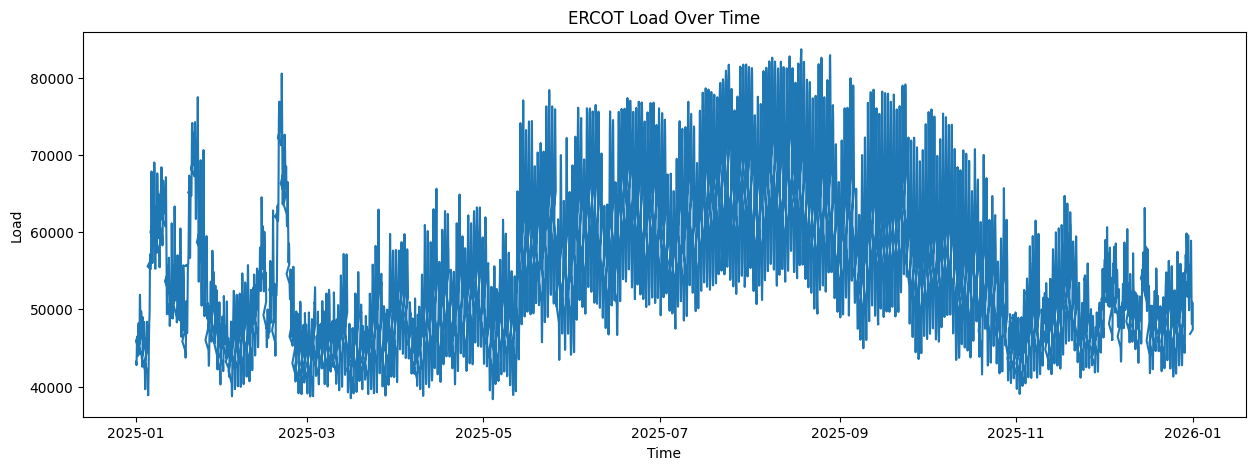

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(df['Hour Ending'], df['ERCOT'])

plt.title('ERCOT Load Over Time')
plt.xlabel('Time')
plt.ylabel('Load')

plt.show()

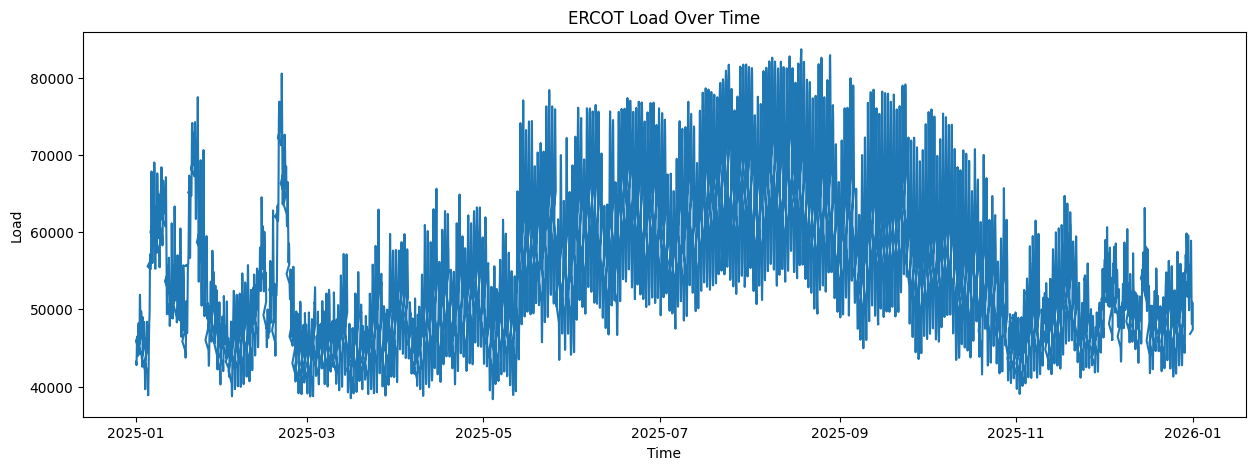

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(df['Hour Ending'], df['ERCOT'])

plt.title('ERCOT Load Over Time')
plt.xlabel('Time')
plt.ylabel('Load')

plt.show()

    Raw 2025 ERCOT load over time
    Shows seasonal behavior clearly: summer load is much higher and more volatile.

In [12]:
df.loc[df['ERCOT'].idxmax()]

,5512
Hour Ending,2025-08-18 18:00:00
COAST,22349.497921
EAST,2888.690723
FWEST,7046.24676
NORTH,1942.520791
NCENT,26581.624761
SOUTH,6508.846311
SCENT,14519.96276
WEST,1841.611669
ERCOT,83679.001697


    Max load moment
    Peak is Aug 18, 2025 at 6 PM around 83,679 MW — very summer/HVAC-driven.
    

In [14]:
df['Hour'] = df['Hour Ending'].dt.hour

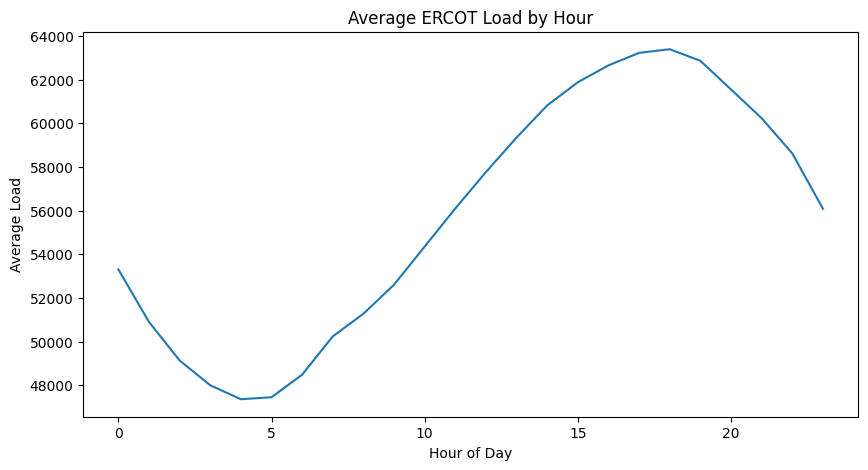

In [15]:
hourly_avg = df.groupby('Hour')['ERCOT'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_avg.index, hourly_avg.values)

plt.title('Average ERCOT Load by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Load')

plt.show()

    Average load by hour
    Nice smooth daily demand rhythm.


# 4. Seasonal Patterns


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Create date/month/season columns
df['Date'] = df['Hour Ending'].dt.date
df['Month'] = df['Hour Ending'].dt.month

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)

df[['Hour Ending', 'Hour', 'Month', 'Season', 'ERCOT']].head()

,Hour Ending,Hour,Month,Season,ERCOT
0,2025-01-01 01:00:00,1,1,Winter,43223.859905
1,2025-01-01 02:00:00,2,1,Winter,43122.532212
2,2025-01-01 03:00:00,3,1,Winter,42918.511847
3,2025-01-01 04:00:00,4,1,Winter,42780.783583
4,2025-01-01 05:00:00,5,1,Winter,43253.234707


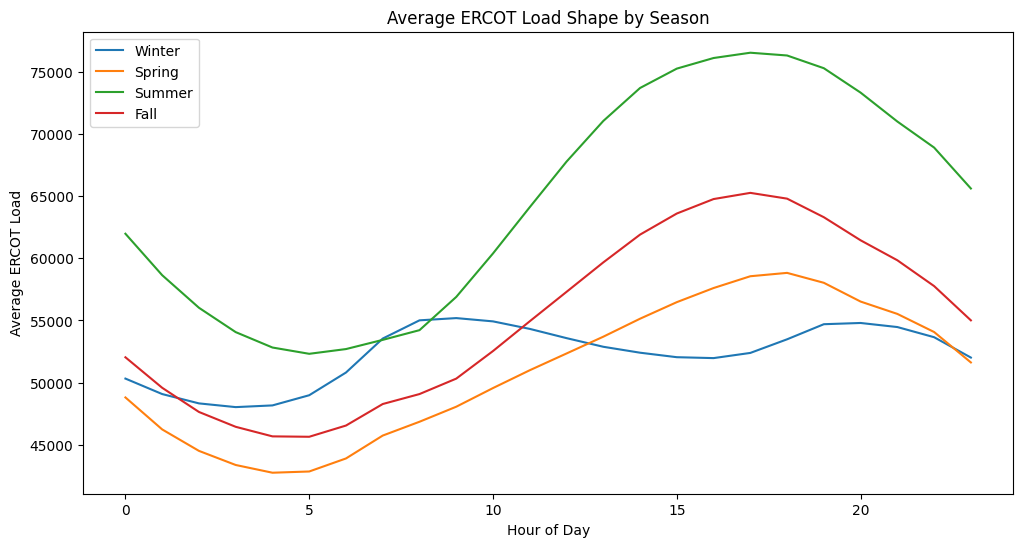

In [17]:
seasonal_hourly = (
    df.groupby(['Season', 'Hour'])['ERCOT']
    .mean()
    .reset_index()
)

season_order = ['Winter', 'Spring', 'Summer', 'Fall']

plt.figure(figsize=(12,6))

for season in season_order:
    subset = seasonal_hourly[seasonal_hourly['Season'] == season]
    plt.plot(subset['Hour'], subset['ERCOT'], label=season)

plt.title('Average ERCOT Load Shape by Season')
plt.xlabel('Hour of Day')
plt.ylabel('Average ERCOT Load')
plt.legend()
plt.show()

    shows winter behaves differently from summer/fall.

In [18]:
df = df.sort_values('Hour Ending')

df['Load_Change'] = df['ERCOT'].diff()
df['Abs_Load_Change'] = df['Load_Change'].abs()

df[['Hour Ending', 'ERCOT', 'Load_Change', 'Abs_Load_Change']].head()

,Hour Ending,ERCOT,Load_Change,Abs_Load_Change
23,2025-01-01 00:00:00,45875.362111,NaN,NaN
0,2025-01-01 01:00:00,43223.859905,-2651.502206,2651.502206
1,2025-01-01 02:00:00,43122.532212,-101.327693,101.327693
2,2025-01-01 03:00:00,42918.511847,-204.020365,204.020365
3,2025-01-01 04:00:00,42780.783583,-137.728264,137.728264


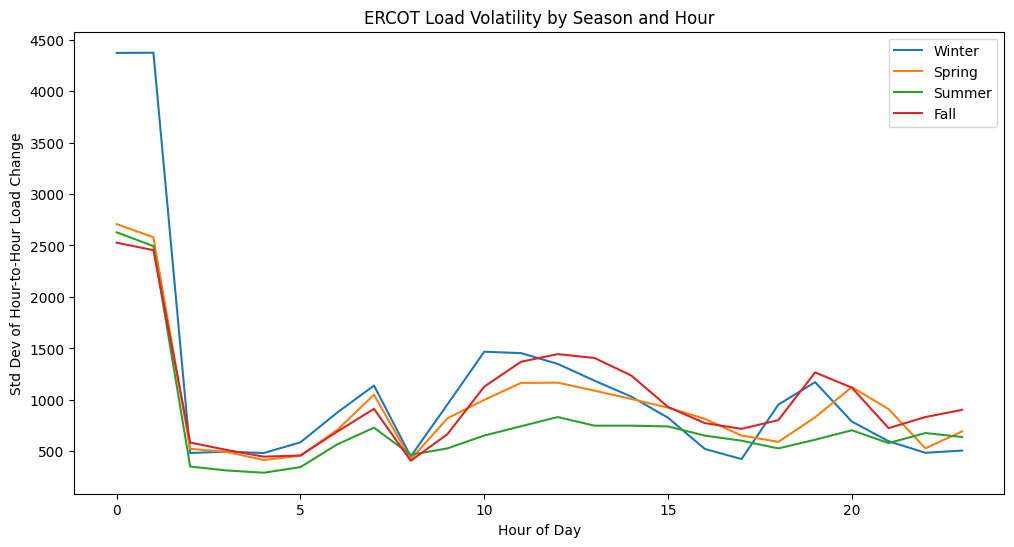

In [19]:
seasonal_volatility = (
    df.groupby(['Season', 'Hour'])['Load_Change']
    .std()
    .reset_index()
)

plt.figure(figsize=(12,6))

for season in season_order:
    subset = seasonal_volatility[seasonal_volatility['Season'] == season]
    plt.plot(subset['Hour'], subset['Load_Change'], label=season)

plt.title('ERCOT Load Volatility by Season and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Std Dev of Hour-to-Hour Load Change')
plt.legend()
plt.show()


# 5. Stress vs Normal Days


In [21]:
daily_peak = df.groupby('Date')['ERCOT'].max()

stress_threshold = daily_peak.quantile(0.90)
print("Stress threshold:", stress_threshold)


stress_days = daily_peak[daily_peak >= stress_threshold].index

df['Day_Type'] = np.where(df['Date'].isin(stress_days), 'Stress', 'Normal')

df[['Hour Ending', 'Date', 'ERCOT', 'Day_Type']].head()

Stress threshold: 78507.1686474


,Hour Ending,Date,ERCOT,Day_Type
23,2025-01-01 00:00:00,2025-01-01,45875.362111,Normal
0,2025-01-01 01:00:00,2025-01-01,43223.859905,Normal
1,2025-01-01 02:00:00,2025-01-01,43122.532212,Normal
2,2025-01-01 03:00:00,2025-01-01,42918.511847,Normal
3,2025-01-01 04:00:00,2025-01-01,42780.783583,Normal


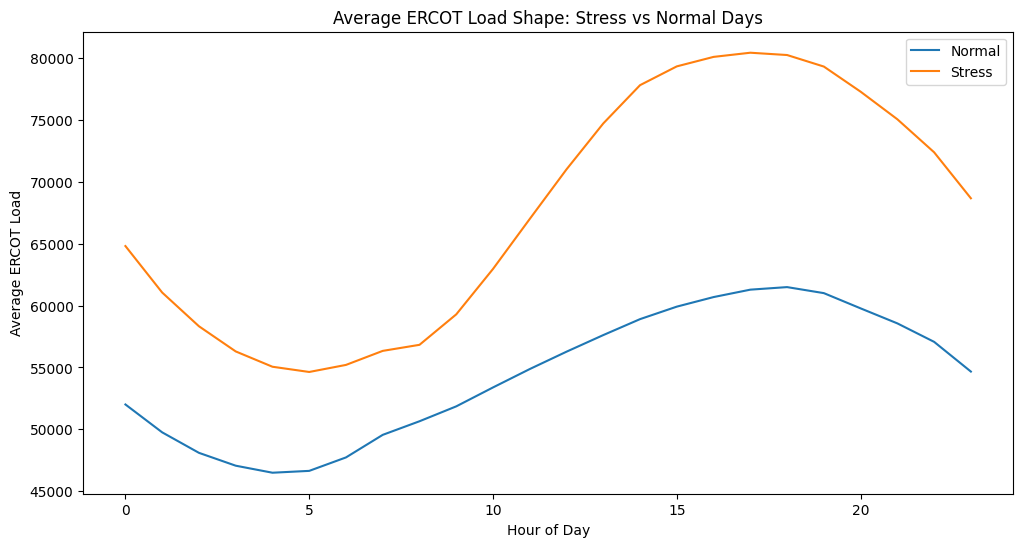

In [22]:
stress_hourly = (
    df.groupby(['Day_Type', 'Hour'])['ERCOT']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

for day_type in ['Normal', 'Stress']:
    subset = stress_hourly[stress_hourly['Day_Type'] == day_type]
    plt.plot(subset['Hour'], subset['ERCOT'], label=day_type)

plt.title('Average ERCOT Load Shape: Stress vs Normal Days')
plt.xlabel('Hour of Day')
plt.ylabel('Average ERCOT Load')
plt.legend()
plt.show()

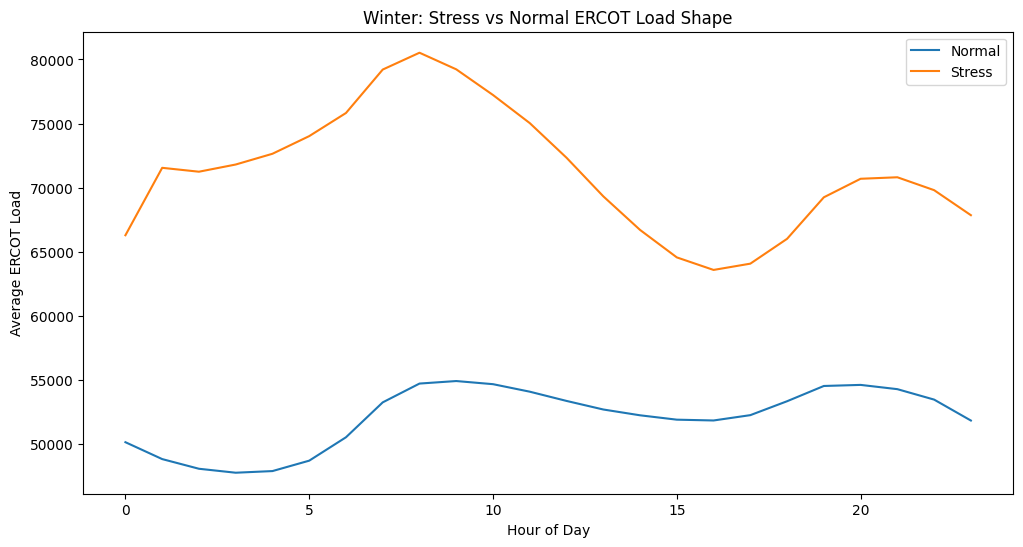

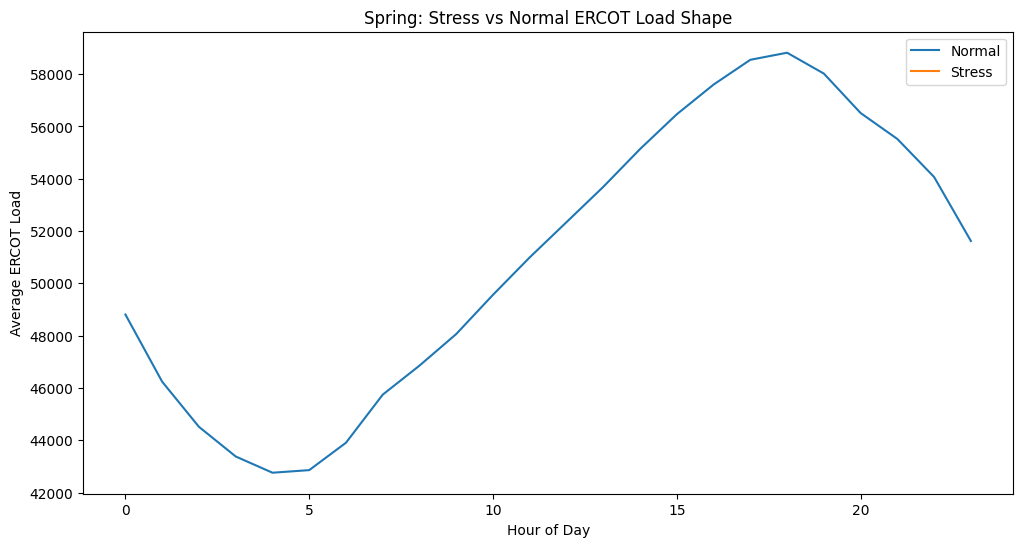

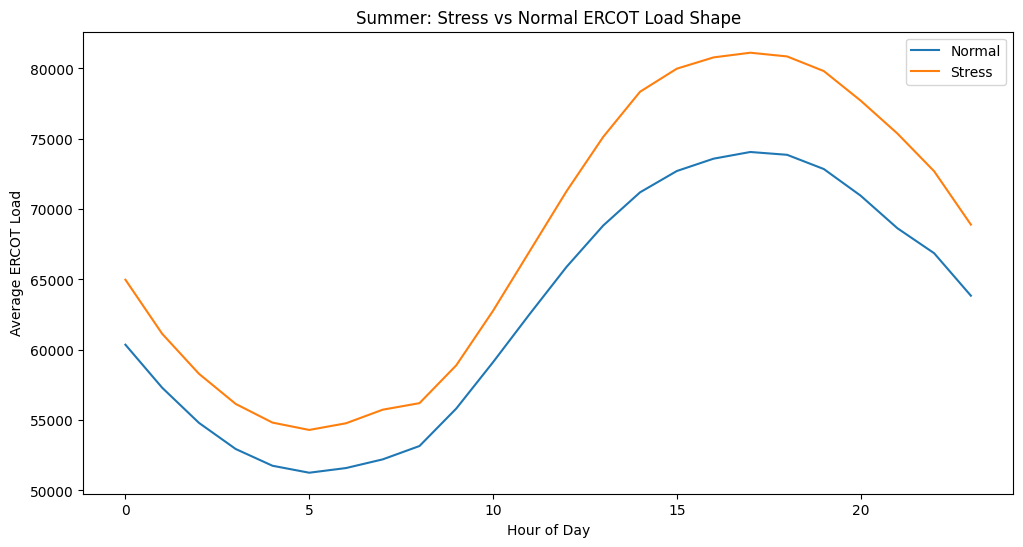

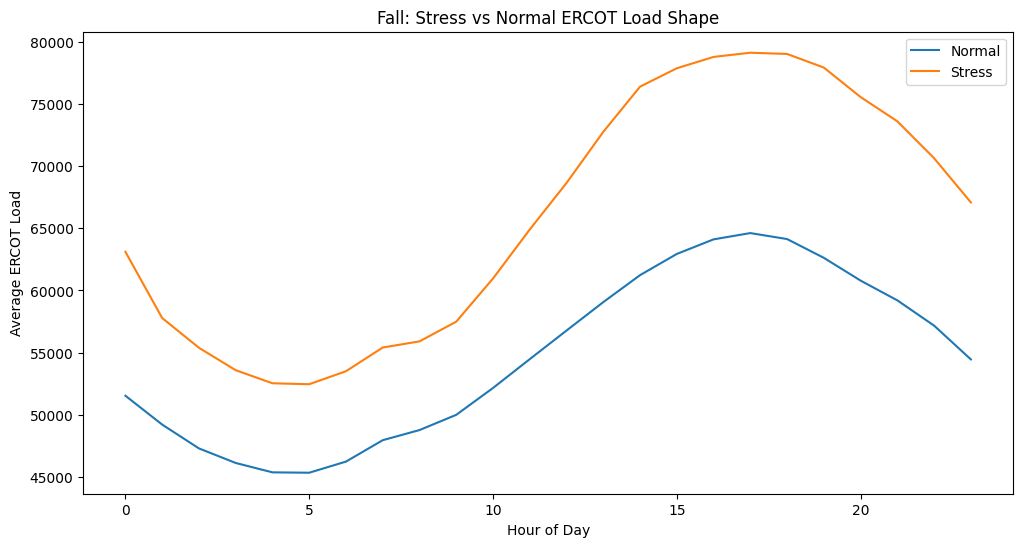

In [23]:
season_stress_hourly = (
    df.groupby(['Season', 'Day_Type', 'Hour'])['ERCOT']
    .mean()
    .reset_index()
)

for season in season_order:
    subset_season = season_stress_hourly[season_stress_hourly['Season'] == season]

    plt.figure(figsize=(12,6))

    for day_type in ['Normal', 'Stress']:
        subset = subset_season[subset_season['Day_Type'] == day_type]
        plt.plot(subset['Hour'], subset['ERCOT'], label=day_type)

    plt.title(f'{season}: Stress vs Normal ERCOT Load Shape')
    plt.xlabel('Hour of Day')
    plt.ylabel('Average ERCOT Load')
    plt.legend()
    plt.show()

In [24]:
# Define stress days within each season instead of across the whole year

daily = (
    df.groupby(['Date', 'Season'])['ERCOT']
    .max()
    .reset_index(name='Daily_Peak')
)

daily['Season_Stress_Threshold'] = daily.groupby('Season')['Daily_Peak'].transform(
    lambda x: x.quantile(0.90)
)

daily['Season_Day_Type'] = np.where(
    daily['Daily_Peak'] >= daily['Season_Stress_Threshold'],
    'Stress',
    'Normal'
)

df = df.merge(
    daily[['Date', 'Season_Day_Type']],
    on='Date',
    how='left'
)

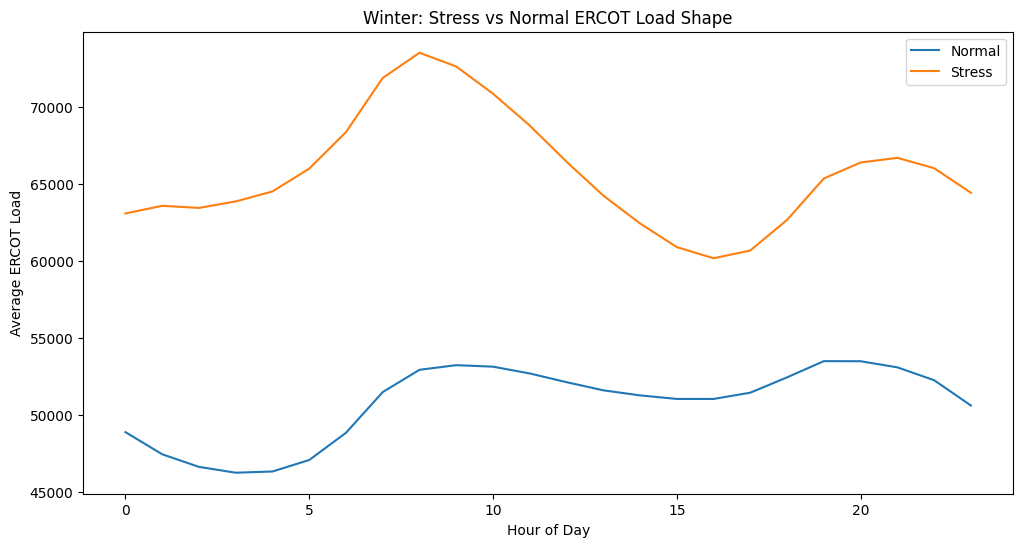

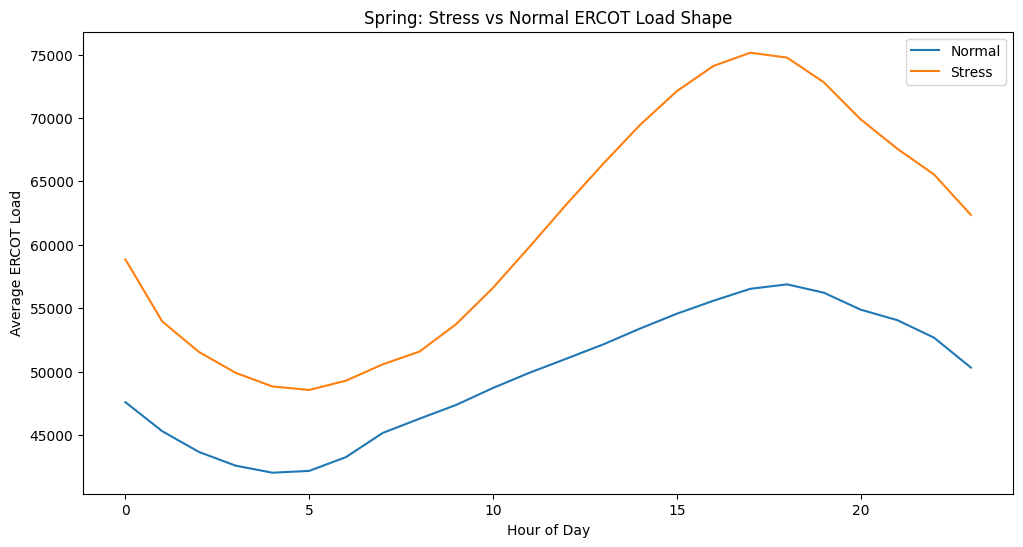

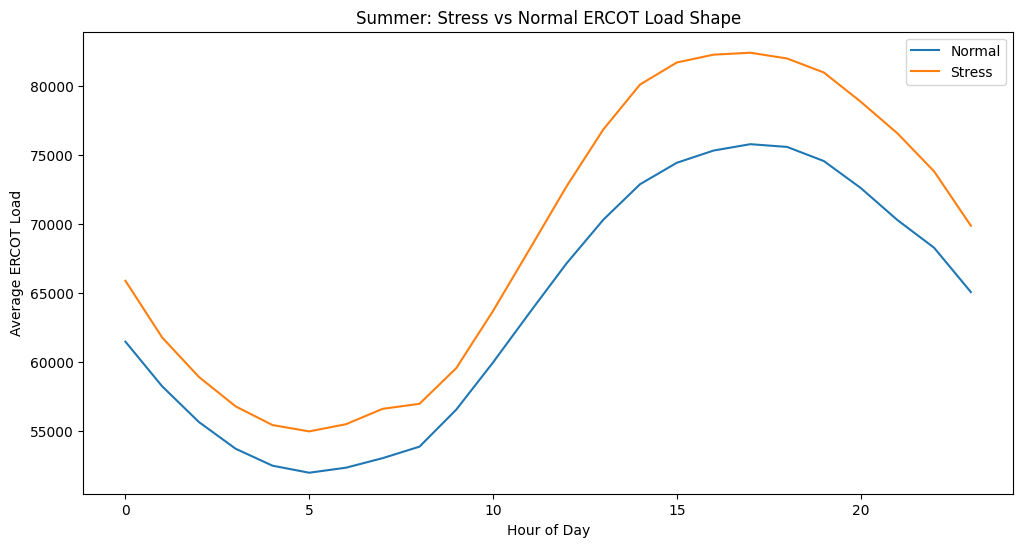

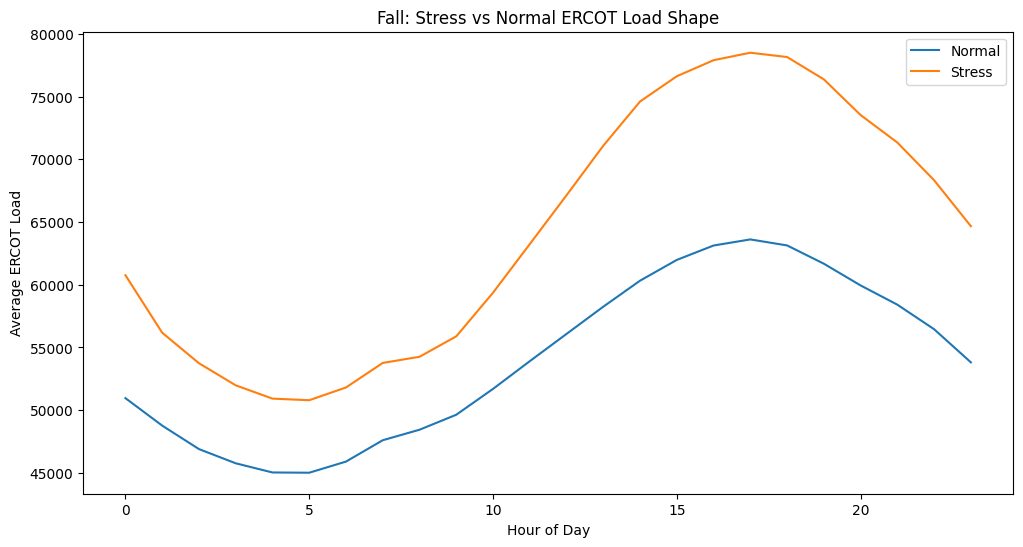

In [26]:
season_stress_hourly = (
    df.groupby(['Season', 'Season_Day_Type', 'Hour'])['ERCOT']
    .mean()
    .reset_index()
)

season_order = ['Winter', 'Spring', 'Summer', 'Fall']

for season in season_order:
    subset_season = season_stress_hourly[season_stress_hourly['Season'] == season]

    plt.figure(figsize=(12,6))

    for day_type in ['Normal', 'Stress']:
        subset = subset_season[subset_season['Season_Day_Type'] == day_type]
        plt.plot(subset['Hour'], subset['ERCOT'], label=day_type)

    plt.title(f'{season}: Stress vs Normal ERCOT Load Shape')
    plt.xlabel('Hour of Day')
    plt.ylabel('Average ERCOT Load')
    plt.legend()
    plt.show()

Winter ERCOT stress is driven by persistent heating demand and morning ramp behavior rather than solar/AC afternoon peaks.Winter ERCOT stress is driven by persistent heating demand and morning ramp behavior rather than solar/AC afternoon peaks.


ERCOT can absorb spring load growth more smoothly because weather volatility is lower.

Summer stress is not anomalous behavior.
It is amplification of normal ERCOT summer dynamics

Fall is intereting because its alomst behaving like a mini summer.

In [27]:

# 6. Add Weather Data
# 7. Weather vs Load Analysis
# 8. Initial Findings

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
# Loading NOAA Weather Data
weather_path = '/content/drive/MyDrive/energy-reliability-systems/data/LCD_USW00012918_2025.csv'

weather = pd.read_csv(weather_path)


/tmp/ipykernel_15031/2095840352.py:4: DtypeWarning: Columns (19,23,27,33,34,35,36,42,60,61,90,91,92,93,94,95,96,97,98,99,100,101,113) have mixed types. Specify dtype option on import or set low_memory=False.
  weather = pd.read_csv(weather_path)


In [41]:
# Preview data
print("Weather Data Preview:")
display(weather.head())

print("\nWeather Columns:")
print(weather.columns)



Weather Data Preview:


,STATION,DATE,LATITUDE,LONGITUDE,ELEVATION,NAME,REPORT_TYPE,SOURCE,HourlyAltimeterSetting,HourlyDewPointTemperature,...,BackupDirection,BackupDistance,BackupDistanceUnit,BackupElements,BackupElevation,BackupEquipment,BackupLatitude,BackupLongitude,BackupName,WindEquipmentChangeDate
0,USW00012918,2025-01-01T00:00:00,29.63806,-95.28194,13.4,"HOUSTON WILLIAM P HOBBY AIRPORT, TX US",SOD,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,06/27/2007
1,USW00012918,2025-01-01T00:53:00,29.63806,-95.28194,13.4,"HOUSTON WILLIAM P HOBBY AIRPORT, TX US",FM-15,343.0,1021.0,4.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,06/27/2007
2,USW00012918,2025-01-01T01:53:00,29.63806,-95.28194,13.4,"HOUSTON WILLIAM P HOBBY AIRPORT, TX US",FM-15,343.0,1021.7,4.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,06/27/2007
3,USW00012918,2025-01-01T02:53:00,29.63806,-95.28194,13.4,"HOUSTON WILLIAM P HOBBY AIRPORT, TX US",FM-15,343.0,1022.0,4.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,06/27/2007
4,USW00012918,2025-01-01T03:53:00,29.63806,-95.28194,13.4,"HOUSTON WILLIAM P HOBBY AIRPORT, TX US",FM-15,343.0,1022.4,4.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,06/27/2007



Weather Columns:
Index(['STATION', 'DATE', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'NAME',
       'REPORT_TYPE', 'SOURCE', 'HourlyAltimeterSetting',
       'HourlyDewPointTemperature',
       ...
       'BackupDirection', 'BackupDistance', 'BackupDistanceUnit',
       'BackupElements', 'BackupElevation', 'BackupEquipment',
       'BackupLatitude', 'BackupLongitude', 'BackupName',
       'WindEquipmentChangeDate'],
      dtype='object', length=125)


In [42]:
# Clean Weather Data

# Convert datetime column
weather['DATE'] = pd.to_datetime(weather['DATE'])

# Convert temperature column to numeric
weather['HourlyDryBulbTemperature'] = pd.to_numeric(
    weather['HourlyDryBulbTemperature'],
    errors='coerce'
)

# Keeping only columns I need
weather_clean = weather[
    ['DATE', 'HourlyDryBulbTemperature']
].dropna()

print("\nCleaned Weather Data:")
display(weather_clean.head())



Cleaned Weather Data:


,DATE,HourlyDryBulbTemperature
1,2025-01-01 00:53:00,13.3
2,2025-01-01 01:53:00,12.2
3,2025-01-01 02:53:00,11.7
4,2025-01-01 03:53:00,11.1
5,2025-01-01 04:53:00,10.6


In [43]:
# Prepare ERCOT Data

# Make sure ERCOT timestamps are datetime
df['Hour Ending'] = pd.to_datetime(df['Hour Ending'])

# Sort both datasets
df_sorted = df.sort_values('Hour Ending')
weather_sorted = weather_clean.sort_values('DATE')


In [44]:
# Merge Weather + ERCOT

merged = pd.merge_asof(
    df_sorted,
    weather_sorted,
    left_on='Hour Ending',
    right_on='DATE',
    direction='nearest'
)

print("\nMerged Dataset:")
display(merged.head())



Merged Dataset:


,Hour Ending,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT,Hour,Date,Month,Season,Load_Change,Abs_Load_Change,Day_Type,Season_Day_Type,DATE,HourlyDryBulbTemperature
0,2025-01-01 00:00:00,11034.358814,1652.581239,7136.447964,1465.449832,13431.830740,3258.146198,6625.440094,1271.107229,45875.362111,0,2025-01-01,1,Winter,NaN,NaN,Normal,Normal,2025-01-01 00:53:00,13.3
1,2025-01-01 01:00:00,10538.553193,1545.465863,7090.619810,1388.565588,11964.866264,3012.769998,6447.297871,1235.721317,43223.859905,1,2025-01-01,1,Winter,-2651.502206,2651.502206,Normal,Normal,2025-01-01 00:53:00,13.3
2,2025-01-01 02:00:00,10477.912860,1553.994477,7040.460607,1390.392647,12064.919506,2962.803597,6382.650858,1249.397659,43122.532212,2,2025-01-01,1,Winter,-101.327693,101.327693,Normal,Normal,2025-01-01 01:53:00,12.2
3,2025-01-01 03:00:00,10363.015361,1534.575620,7028.741719,1390.634577,12040.262276,2981.433181,6320.119991,1259.729121,42918.511847,3,2025-01-01,1,Winter,-204.020365,204.020365,Normal,Normal,2025-01-01 02:53:00,11.7
4,2025-01-01 04:00:00,10259.984795,1548.084385,6992.734978,1402.423965,12055.424000,2970.761172,6277.132219,1274.238069,42780.783583,4,2025-01-01,1,Winter,-137.728264,137.728264,Normal,Normal,2025-01-01 03:53:00,11.1


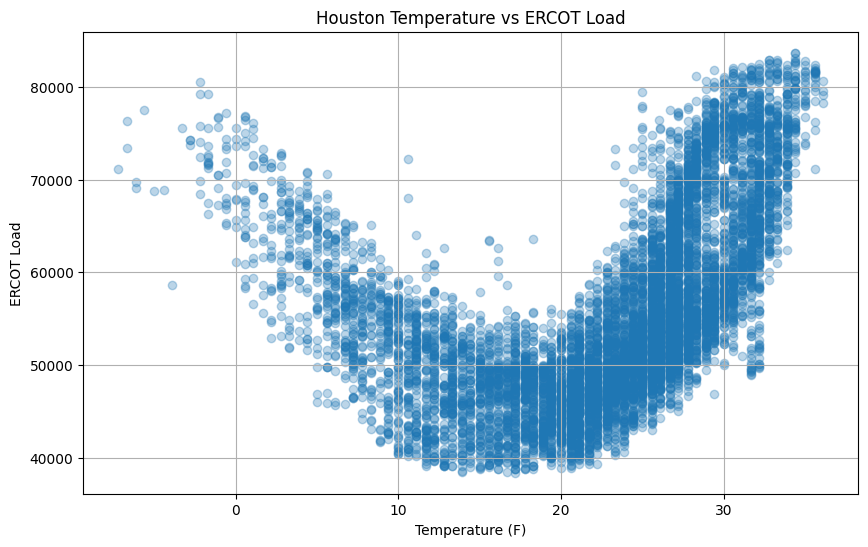

In [45]:
#  Temperature vs ERCOT Load

plt.figure(figsize=(10,6))

plt.scatter(
    merged['HourlyDryBulbTemperature'],
    merged['ERCOT'],
    alpha=0.3
)

plt.title('Houston Temperature vs ERCOT Load')
plt.xlabel('Temperature (F)')
plt.ylabel('ERCOT Load')

plt.grid(True)
plt.show()


At mild temperatures (~15–20°C / ~60–70°F equivalent), ERCOT load is lowest.

As temperatures move:

* colder → heating demand rises
* hotter → AC demand rises

That’s why the shape bends upward on BOTH sides.

In [46]:
# Correlation

correlation = merged[
    ['HourlyDryBulbTemperature', 'ERCOT']
].corr()

print("\nCorrelation Matrix:")
print(correlation)


Correlation Matrix:
                          HourlyDryBulbTemperature     ERCOT
HourlyDryBulbTemperature                  1.000000  0.420947
ERCOT                                     0.420947  1.000000


correlation being only ~0.42 is actually interesting because:

* the relationship is nonlinear
* simple Pearson correlation underestimates weather effects
* this is exactly why utilities use nonlinear load forecasting models

In [47]:
merged['Temp_F'] = (merged['HourlyDryBulbTemperature'] * 9/5) + 32

changing to fahrenheit

In [48]:
merged['Hour'] = merged['Hour Ending'].dt.hour

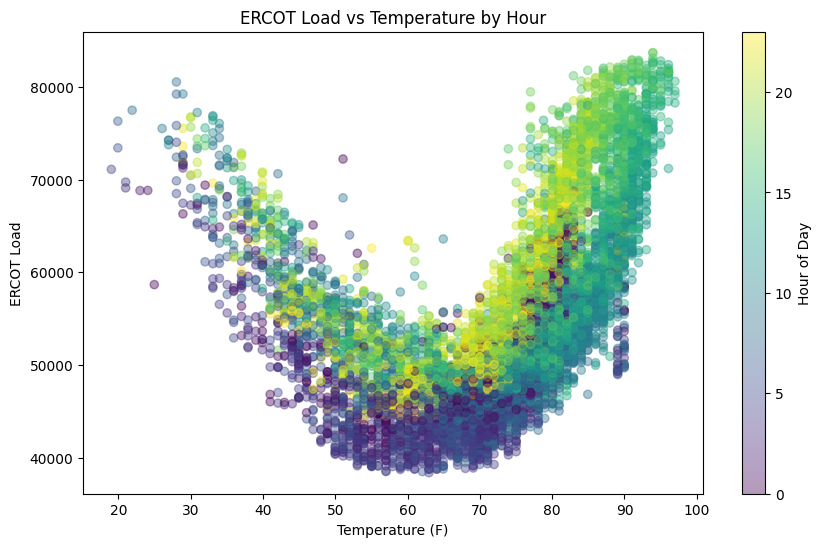

In [49]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    merged['Temp_F'],
    merged['ERCOT'],
    c=merged['Hour'],
    alpha=0.4
)

plt.colorbar(label='Hour of Day')

plt.xlabel('Temperature (F)')
plt.ylabel('ERCOT Load')
plt.title('ERCOT Load vs Temperature by Hour')

plt.show()


## Observation: Temperature, Time of Day, and ERCOT Load

This scatterplot shows a nonlinear relationship between Houston temperature and ERCOT load. Load is lowest during mild temperatures and rises when temperatures become very cold or very hot.

The color gradient adds an important timing layer: hotter temperatures are concentrated later in the day, while colder temperatures are more common overnight and early morning. This suggests that ERCOT load is shaped not only by temperature, but also by the timing of human activity and weather cycles.

The hot-weather side of the curve appears steeper, indicating that ERCOT demand may be more sensitive to extreme heat than to moderate cold conditions.

In [50]:
merged['Load_Deviation'] = (
    merged['ERCOT'] - merged['ERCOT'].mean()
) / merged['ERCOT'].std()


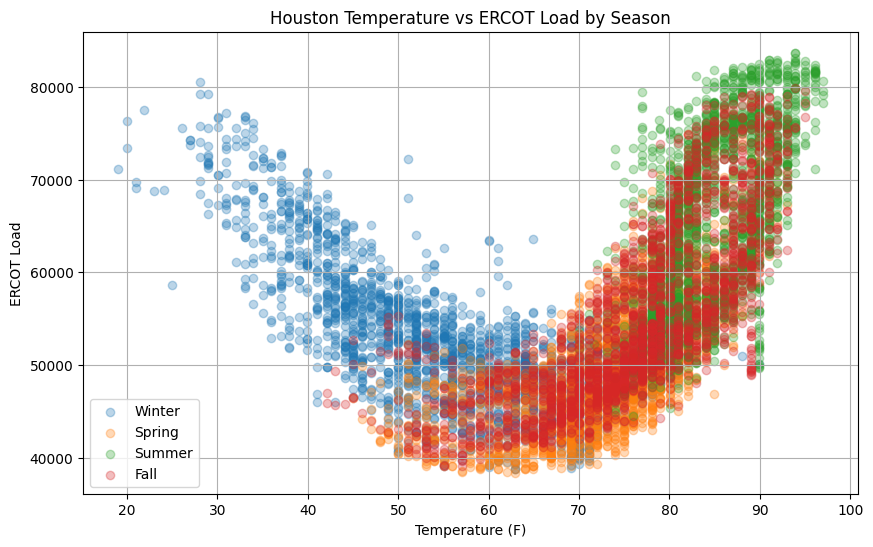

In [52]:
# Temperature vs Load by Season

plt.figure(figsize=(10,6))

for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    subset = merged[merged['Season'] == season]

    plt.scatter(
        subset['Temp_F'],
        subset['ERCOT'],
        alpha=0.3,
        label=season
    )

plt.title('Houston Temperature vs ERCOT Load by Season')
plt.xlabel('Temperature (F)')
plt.ylabel('ERCOT Load')
plt.legend()
plt.grid(True)
plt.show()

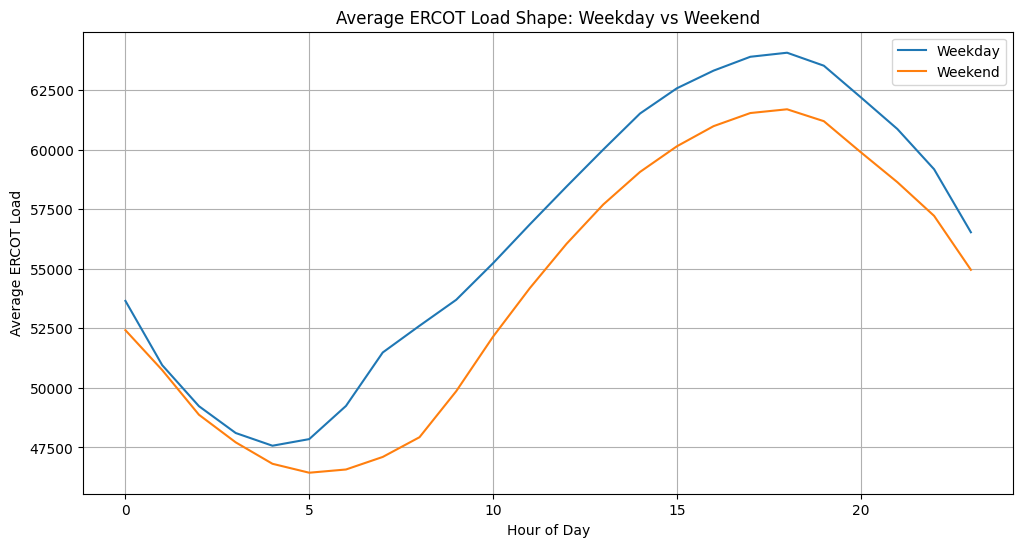

In [56]:
# Weekday vs Weekend Load Behavior

merged['DayOfWeek'] = merged['Hour Ending'].dt.dayofweek

merged['Day_Category'] = np.where(
    merged['DayOfWeek'].isin([5, 6]),
    'Weekend',
    'Weekday'
)

weekday_hourly = (
    merged.groupby(['Day_Category', 'Hour'])['ERCOT']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

for day_type in ['Weekday', 'Weekend']:
    subset = weekday_hourly[weekday_hourly['Day_Category'] == day_type]

    plt.plot(
        subset['Hour'],
        subset['ERCOT'],
        label=day_type
    )

plt.title('Average ERCOT Load Shape: Weekday vs Weekend')
plt.xlabel('Hour of Day')
plt.ylabel('Average ERCOT Load')
plt.legend()
plt.grid(True)
plt.show()

## Observation: Weekday vs Weekend Load Behavior

ERCOT load follows a similar daily shape on both weekdays and weekends, but weekday demand is consistently higher throughout most of the day.

The largest divergence appears during business hours and the late afternoon peak period, likely reflecting commercial and industrial activity. Weekend demand rises more gradually and reaches a lower peak overall.

This suggests that human behavior and economic activity patterns materially influence grid demand beyond weather effects alone.

Mean Absolute Error: 1925.0820067036357
R-squared: 0.9322510718214299


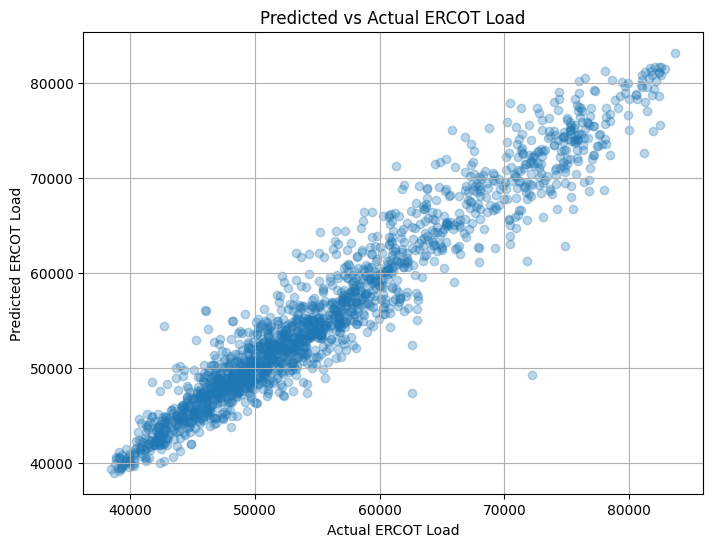

In [57]:
# Basic Peak Load Predictor

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model_df = merged.copy()

model_df['IsWeekend'] = np.where(model_df['DayOfWeek'].isin([5, 6]), 1, 0)
model_df['Month'] = model_df['Hour Ending'].dt.month

model_df = model_df.dropna(subset=['Temp_F', 'Hour', 'DayOfWeek', 'Month', 'ERCOT'])

features = ['Temp_F', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend']
target = 'ERCOT'

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R-squared:", r2)

plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions, alpha=0.3)

plt.title('Predicted vs Actual ERCOT Load')
plt.xlabel('Actual ERCOT Load')
plt.ylabel('Predicted ERCOT Load')
plt.grid(True)
plt.show()

## Observation: ERCOT Load Prediction Model

The Random Forest model performs well at predicting ERCOT load using temperature, hour of day, calendar features, and weekend indicators.

Predicted values closely follow actual load observations, indicating that weather and temporal variables explain a significant portion of ERCOT demand variability.

Prediction spread increases during higher load conditions, suggesting that extreme demand periods may involve additional drivers such as market behavior, outages, or rapid weather shifts.

In [58]:
#  Extreme Day Detection
daily_summary = (
    merged.groupby('Date')
    .agg(
        Daily_Peak_Load=('ERCOT', 'max'),
        Daily_Avg_Load=('ERCOT', 'mean'),
        Daily_Max_Temp=('Temp_F', 'max'),
        Daily_Min_Temp=('Temp_F', 'min'),
        Daily_Avg_Temp=('Temp_F', 'mean'),
        Max_Hourly_Ramp=('Abs_Load_Change', 'max')
    )
    .reset_index()
)

peak_threshold = daily_summary['Daily_Peak_Load'].quantile(0.95)
ramp_threshold = daily_summary['Max_Hourly_Ramp'].quantile(0.95)
temp_threshold = daily_summary['Daily_Max_Temp'].quantile(0.95)

daily_summary['Extreme_Day'] = np.where(
    (daily_summary['Daily_Peak_Load'] >= peak_threshold) |
    (daily_summary['Max_Hourly_Ramp'] >= ramp_threshold) |
    (daily_summary['Daily_Max_Temp'] >= temp_threshold),
    'Extreme',
    'Normal'
)

daily_summary.sort_values('Daily_Peak_Load', ascending=False).head(10)

,Date,Daily_Peak_Load,Daily_Avg_Load,Daily_Max_Temp,Daily_Min_Temp,Daily_Avg_Temp,Max_Hourly_Ramp,Extreme_Day
229,2025-08-18,83679.001697,70185.283074,96.08,80.06,87.2375,4970.630721,Extreme
239,2025-08-28,82907.273669,68467.484765,93.92,78.08,85.1600,4134.059997,Extreme
225,2025-08-14,82757.910024,69775.173452,95.00,80.06,87.0425,8055.818848,Extreme
219,2025-08-08,82589.021176,69993.000666,96.08,78.98,86.0375,5309.413063,Extreme
236,2025-08-25,82580.922424,67196.727202,93.92,78.08,85.3700,4559.818674,Extreme
218,2025-08-07,82111.271583,69131.606702,95.00,78.98,85.3775,4760.744204,Extreme
220,2025-08-09,82079.043659,68746.926833,93.92,80.06,85.5125,5707.193837,Extreme
222,2025-08-11,82061.278338,68527.376784,93.02,78.08,85.0925,4644.133657,Extreme
230,2025-08-19,82053.227132,68514.793413,91.94,80.96,84.9875,6703.139511,Extreme
228,2025-08-17,81823.878801,68078.482707,96.98,78.08,86.8700,4734.361965,Extreme


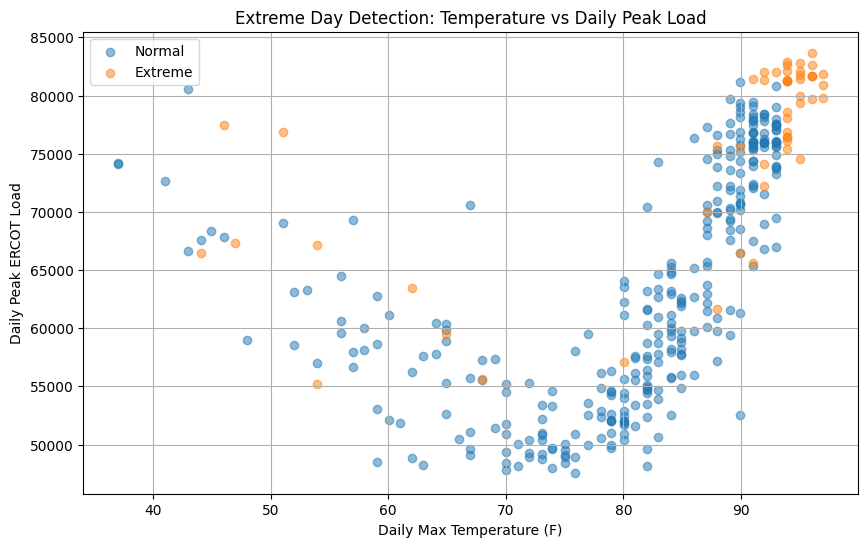

In [61]:
# Visualize extreme days

plt.figure(figsize=(10,6))

for label in ['Normal', 'Extreme']:
    subset = daily_summary[daily_summary['Extreme_Day'] == label]

    plt.scatter(
        subset['Daily_Max_Temp'],
        subset['Daily_Peak_Load'],
        alpha=0.5,
        label=label
    )

plt.title('Extreme Day Detection: Temperature vs Daily Peak Load')
plt.xlabel('Daily Max Temperature (F)')
plt.ylabel('Daily Peak ERCOT Load')
plt.legend()
plt.grid(True)
plt.show()

## Observation: Extreme Day Detection

Extreme ERCOT load days cluster primarily around very high temperatures, reinforcing the strong relationship between heat and grid stress in Texas.

A smaller number of extreme days also occur during colder conditions, likely associated with winter heating demand and weather-related operational stress.

The visualization suggests that high-temperature events are more consistently associated with peak system demand than moderate temperature ranges.